<img style="float: center;" src='./assets/jwebbinar.png' width="1000px"/> 

## JWebbinar 49
_June 25, 2026_
## JHAT Examples

### Author: Justin Pierel (STScI), Armin Rest (STScI)

**Purpose**:<BR>
This notebook has a couple of common use cases for JWST alignment, using the JHAT package. First is aligning data to an external catalog, and second is aligning between instruments (MIRI to NIRCam). 

**Data**:<BR>
This example is set up to use an example dataset from the JADES program, followed by some early JWST data from an ERS program 2727 covering the Supernova 2021afdx. 


<hr style="border:1px solid gray"> </hr>

## Table of Contents
1. Aligning to an external catalog
2. Aligning MIRI to NIRCam
    


# 1. Section 1 - Align to catalog

<hr style="border:1px solid gray"> </hr>

In [1]:
# Package imports
from jwst.datamodels import ImageModel
from pathlib import Path
import re,os
import jhat
import matplotlib.pyplot as plt
from astropy.table import Table
import os

## If you have a CRDS issue, try uncommenting the following three lines
# os.environ["CRDS_PATH"] = os.path.expanduser("~/crds_cache/jwst")
# os.environ["CRDS_SERVER_URL"] = "https://jwst-crds.stsci.edu"

# os.makedirs(os.environ["CRDS_PATH"], exist_ok=True)

Maintenance with possible short-time disconnections: 29 June 2026 18:00–20:00 CEST
The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


##### Let's start with creating our catalog from an image, i.e., a relative alignment. You could also bring in this catalog from any external source as long as it has the key column names of ra, dec, mag, and magerr. 

In [2]:
data_dir = Path(os.environ.get("JWEBBINAR_49_DATA", "../data"))
out_dir = Path(os.environ.get("JWEBBINAR_49_OUT", "../data"))
input_image = str(data_dir / 'jw01180013001_10101_00005_nrcb2_cal.fits')
outrootdir = str(out_dir / 'aligned')
outsubdir = 'cat_example'
telescope = 'jwst'
reference_image = str(data_dir / 'jades_template_example_i2d.fits')

wcs_align = jhat.st_wcs_align()
verbose=2
wcs_align.verbose=verbose

# first rough cut: best d_rotated+-rough_cut_pix. This is the upper limit for rough_cut
wcs_align.rough_cut_px_min = wcs_align.rough_cut_px_max = 1.5


In [3]:
wcs_align.set_outbasename(outrootdir=outrootdir,outsubdir=outsubdir,inputname=reference_image)
# set the telescope
wcs_align.set_telescope(telescope=telescope,imname=reference_image)


telescope set to jwst


In [4]:
wcs_align.phot.verbose = wcs_align.verbose
refcatfilename = f'{wcs_align.outbasename}.phot.txt'
(refcatfilename_4check,refcat_loaded) = wcs_align.phot.run_phot(reference_image,
                                                          use_dq=True,
                                                          photfilename=refcatfilename,
                                                          overwrite=True)


### Doing photometry on ../data/jades_template_example_i2d.fits
2 ../data/aligned/cat_example/jades_template_example.phot.txt
photometry catalog filename: ../data/aligned/cat_example/jades_template_example.phot.txt
photcat ../data/aligned/cat_example/jades_template_example.phot.txt already exists, but recreating it since overwrite=True
Instrument: NIRCAM, aperture:NRCB2_FULL
find_stars
Finding stars --- Detector: NRCB2, Filter: F200W
FWHM for the filter F200W: 2.141 px
Background and rms using MMMBackground and MADStdBackgroundRMS: 0.1596781 0.0029603944

Number of sources found in the image: 6063
-------------------------------------



2026-06-24 15:18:11,963 - CRDS - INFO -  Calibration SW Found: jwst 2.0.1 (/Users/jpierel/miniconda3/envs/tweakreg/envs/jwebbinar/lib/python3.12/site-packages/jwst-2.0.1.dist-info)


radii:[np.float32(3.2434003)]pixels radius_sky_in:8.32314395904541 radius_sky_out:13.52510929107666  radius_for_mag:[np.float32(3.2434003)]
Performing aperture photometry for radius r = 3.2434003353118896 px
Time Elapsed: 2.2731478750065435
4232 objects left after removing entries with NaNs in mag or dmag column
dmag 0.36200000000000004
SNR_min cut: 2121 objects left after removing entries dmag>0.36200000000000004 (SNR<3.0)
2121 out of 4232 entries remain in photometry table
Saving ../data/aligned/cat_example/jades_template_example.phot.txt


In [5]:
refcat = Table.read(refcatfilename,format='ascii')
refcat

aper_sum_3.2px,annulus_median_3.2px,aper_bkg_3.2px,aper_sum_bkgsub_3.2px,flux_err_3.2px,mag,dmag,x,y,sharpness,roundness1,roundness2,ra,dec,x_idl,y_idl,RA,DEC
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
5.428939,0.156899,5.185266,0.350577,7.3e-05,29.22456,0.226666,544.519051,2.965848,0.930447,-0.490859,-0.797724,53.140445,-27.825947,-14.970249,-32.083873,53.140445,-27.825947
5.276506,0.157492,5.20486,0.103079,3.2e-05,30.553593,0.324847,1293.8794,3.300772,0.658397,-0.173848,0.260639,53.133384,-27.825945,8.511365,-32.081468,53.133384,-27.825945
5.395464,0.159709,5.278122,0.168822,4.7e-05,30.017944,0.290751,570.714501,4.602909,0.661243,0.397777,0.156916,53.140198,-27.825934,-14.14926,-32.033329,53.140198,-27.825934
5.343688,0.159307,5.264834,0.113449,3.2e-05,30.449516,0.294039,1732.910706,5.423455,0.83342,0.413525,-0.368431,53.129247,-27.825927,22.273656,-31.9921,53.129247,-27.825927
5.563159,0.160634,5.308712,0.36608,3.1e-05,29.177581,0.097076,699.631889,5.908575,0.722798,-0.843915,-0.67764,53.138983,-27.825923,-10.109421,-31.997199,53.138983,-27.825923
5.617735,0.15893,5.252374,0.525654,3.1e-05,28.78477,0.069696,1462.80789,7.126987,0.588248,-0.344363,-0.473682,53.131792,-27.825913,13.805275,-31.954352,53.131792,-27.825913
5.809138,0.171695,5.674262,0.19405,5.4e-05,29.866737,0.290554,1805.172188,7.435501,0.931675,-0.808488,-0.384766,53.128566,-27.82591,24.53923,-31.922872,53.128566,-27.82591
5.574,0.160407,5.301185,0.392505,9.2e-05,29.101905,0.250184,538.943676,7.068466,0.540855,-0.558371,-0.345691,53.140498,-27.825913,-15.14481,-31.953783,53.140498,-27.825913
5.303468,0.158666,5.243655,0.086055,3e-05,30.749584,0.354246,1376.394054,7.70784,0.66799,0.809102,-0.013663,53.132606,-27.825908,11.096721,-31.939512,53.132606,-27.825908


##### Some of the sources in the catalog will be junk, or faint diffuse galaxies. A simple check is to make a magnitude vs. sharpness plot and identify cuts to make that localize the stellar locus. 

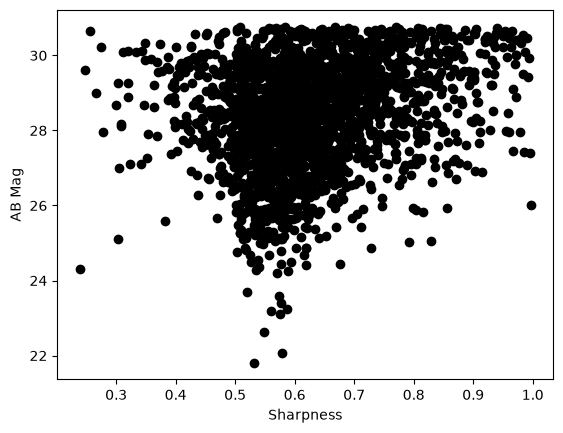

In [6]:
fig,ax = plt.subplots(1,1)
ax.scatter(refcat['sharpness'],refcat['mag'],color='k')
ax.set_ylabel('AB Mag')
ax.set_xlabel('Sharpness')
plt.show()

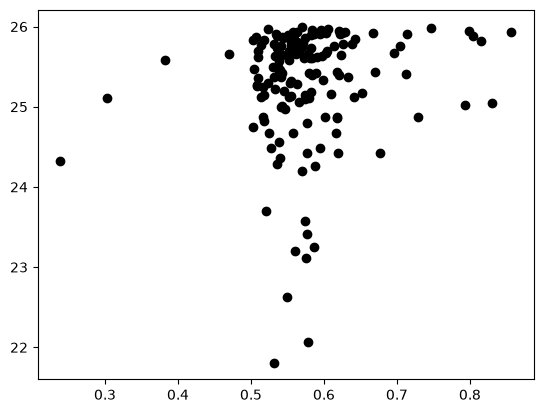

In [7]:
fig,ax = plt.subplots(1,1)
magupper = 26
ax.scatter(refcat[refcat['mag']<magupper]['sharpness'],refcat[refcat['mag']<magupper]['mag'],color='k')
plt.show()

In [8]:
wcs_align.set_outbasename(outrootdir=outrootdir,outsubdir=outsubdir,inputname=input_image)
# set the telescope
wcs_align.set_telescope(telescope=telescope,imname=input_image)


telescope set to jwst


In [9]:
# do the photometry on the target image
xshift=0.0 
yshift=0.0 # This can be estimated if necessary by, e.g., comparing images in DS9 or identifying the stellar locus in later figures
wcs_align.phot.verbose = wcs_align.verbose
photfilename = f'{wcs_align.outbasename}.phot.txt'
(photfilename_4check,photcat_loaded) = wcs_align.phot.run_phot(input_image,
                                                          use_dq=True,
                                                          photfilename=photfilename,
                                                          xshift=xshift,
                                                          yshift=yshift,
                                                          overwrite=True)
# get the indices to the detections
ixs = wcs_align.phot.getindices()



### Doing photometry on ../data/jw01180013001_10101_00005_nrcb2_cal.fits
2 ../data/aligned/cat_example/jw01180013001_10101_00005_nrcb2.phot.txt
photometry catalog filename: ../data/aligned/cat_example/jw01180013001_10101_00005_nrcb2.phot.txt
photcat ../data/aligned/cat_example/jw01180013001_10101_00005_nrcb2.phot.txt already exists, but recreating it since overwrite=True
Instrument: NIRCAM, aperture:NRCB2_FULL
Using DQ extension!!
Applying Pixel Area Map
find_stars
Finding stars --- Detector: NRCB2, Filter: F200W
FWHM for the filter F200W: 2.141 px
Background and rms using MMMBackground and MADStdBackgroundRMS: 0.15431824 0.011663777

Number of sources found in the image: 4374
-------------------------------------



model.meta.resample.pixel_scale_ratio was not found. Assuming the native detector pixel scale (i.e., pixel_scale_ratio = 1)


radii:[np.float32(3.117476)]pixels radius_sky_in:8.0 radius_sky_out:13.0  radius_for_mag:[np.float32(3.117476)]
Performing aperture photometry for radius r = 3.117475986480713 px
Time Elapsed: 1.549584791995585
3024 objects left after removing entries with NaNs in mag or dmag column
dmag 0.36200000000000004
SNR_min cut: 1144 objects left after removing entries dmag>0.36200000000000004 (SNR<3.0)
1144 out of 3024 entries remain in photometry table
Saving ../data/aligned/cat_example/jw01180013001_10101_00005_nrcb2.phot.txt


##### Now we match the target image catalog to the reference catalog we created above. The next two cells do the matching and show the process in a series of figures. 

In [10]:
sharpness_lim=(None,0.9)
roundness1_lim=(-0.75,0.75)
objmag_lim=(17,26)
Nbright=None
refmag_lim = (None,26)
dmag_max = None

# make the initial cut on the image photometry catalog on magnitudes, sharpness, roundness etc
ixs_use = wcs_align.phot.initial_cut_photcat(dmag_max = dmag_max,
                                        sharpness_lim = sharpness_lim, # sharpness limits
                                        roundness1_lim = roundness1_lim, # roundness1 limits 
                                        objmag_lim = objmag_lim, # limits on mag, the magnitude of the objects in the image
                                        Nbright = Nbright,
                                        ixs=ixs)

wcs_align.phot.load_and_match_refcat(ixs_obj=ixs_use,
                                refcatname=refcatfilename,
                                refcat_magcol='mag',
                                refcat_magerrcol='dmag',
                                refcat_racol='ra',
                                refcat_deccol='dec',
                                refmag_lim=refmag_lim, # limits for initial cut
                                refmagerr_lim=refmag_lim, # limits for initial cut, needs to be added to options
                                refcolor_lim=(None,None), # limits for initial cut, needs to be added to options
                                )

# Save the refcat entries!
refcatfilename = f'{wcs_align.outbasename}.refcat.txt'
print(f'Saving refcat file into {refcatfilename}')
wcs_align.phot.refcat.write(refcatfilename,overwrite=True)



########### !!!!!!!!!!  INITIAL CUT on image photometry cat: starting with 3024 objects
SHARPNESS =(None, 0.9) CUT:
sharpness 0.9
2608 left
roundness1=(-0.75, 0.75) CUT:
roundness1 0.75
2278 left
objmag_lim=(17, 26) CUT:
mag 26
110 left
110 of image photometry objects pass initial cuts #1, 2914 cut
Getting ../data/aligned/cat_example/jades_template_example.phot.txt and matching it: ra=53.1320626511901 dec=-27.81764947644948 radius=0.018932870452969854 deg
RA/Dec columns in reference catalog:  ra dec
LOADING refcat ../data/aligned/cat_example/jades_template_example.phot.txt
########### !!!!!!!!!!  INITIAL CUT on reference catalog: starting with 2121 objects
refmag_lim=(None, 26) CUT:
mag 26
152 left
refmagerr_lim=(None, 26) CUT:
dmag 26
152 left
152 of image photometry objects pass initial cuts #1, 1969 cut
Matching reference catalog ../data/aligned/cat_example/jades_template_example.phot.txt
Using 110 image objects that are in x_idl=[-31.71,30.51] and y_idl=[-31.76,31.24] range
x 2008


0

In [ ]:
# maximum distance between source in image and refcat object, in arcsec 
d2d_max = None
# maximum uncertainty
dmag_max = None
# limits on color of image mag and reference color magnitude
delta_mag_lim =(None,None)
slope_min=-0.008
slope_Nsteps = 20 # slope_max=-slope_min, slope_stepsize=(slope_max-slope_min)/slope_Nsteps
Nfwhm = 2.5
show_initial_plot=1
show_histofit_plots=2
savephottable=True
outbasename=wcs_align.outbasename


ixs_bestmatch= wcs_align.find_good_refcat_matches(ixs=ixs_use,
                                             d2d_max = d2d_max,
                                             delta_mag_lim = delta_mag_lim, # limits on mag-refcat_mainfilter
                                             refmag_lim = refmag_lim, # limits on refcat_mainfilter, the magnitude of the reference catalog
                                             slope_min=slope_min, 
                                             slope_Nsteps = slope_Nsteps, # slope_max=-slope_min, slope_stepsize=(slope_max-slope_min)/slope_Nsteps
                                             show_initial_plot=show_initial_plot,
                                             show_histofit_plots=show_histofit_plots,
                                             savephottable=savephottable,
                                             outbasename=outbasename
                                             )     


##### Now we actually apply the matches and correct the WCS of the target image, and show some summary plots. 

In [ ]:
import os

workdir = os.path.join(os.path.expanduser('~'), 'jhat_workdir')
os.makedirs(workdir, exist_ok=True)

# Symlink input image
input_image_local = os.path.join(workdir, os.path.basename(input_image))
if os.path.exists(input_image_local) or os.path.islink(input_image_local):
    os.remove(input_image_local)
os.symlink(input_image, input_image_local)

# Symlink all sidecar files from the wcs_align output directory
catdir = os.path.dirname(wcs_align.outbasename)
for f in os.listdir(catdir):
    link = os.path.join(workdir, f)
    if os.path.exists(link) or os.path.islink(link):
        os.remove(link)
    os.symlink(os.path.join(catdir, f), link)

showplots = 1
saveplots = 1
savephottable = 1
jhatfits = f'{wcs_align.outbasename}_jhat.fits'

(runflag, jhatfits) = wcs_align.run_align2refcat(
    input_image_local,
    outputfits=jhatfits,
    ixs=ixs_bestmatch,
    overwrite=True
)

wcs_align.update_phottable_final_wcs(jhatfits,
                                    ixs_bestmatch = ixs_bestmatch,
                                    showplots=showplots,
                                    saveplots=saveplots,
                                    savephottable=savephottable,
                                    # overwrite=True
                                    )

# Section 2: Aligning MIRI to NIRCam

Now you try! There is a solution notebook in this directory if you get stuck, but use the above example to try and obtain a good alignment between MIRI and NIRCam images below.

In [ ]:
input_image = str(data_dir / 'jw02727007001_02101_00003_mirimage_cal.fits') # F770W 
# input_image = str(data_dir / 'jw02727007001_02107_00002_mirimage_cal.fits') # F1800W
outrootdir = str(out_dir / 'aligned')
outsubdir = 'cat_example'
telescope = 'jwst'
reference_image = str(data_dir / 'jw02727-o002_t062_nircam_clear-f444w_i2d.fits')

wcs_align = jhat.st_wcs_align()
verbose=2
wcs_align.verbose=verbose

